--- Phase 1: Target-Scaled Hyperparameter Optimization ---
Target: Heavy_Metals_Hg_ug_L   | Best R²: 1.0000 | Config: {'epsilon': 0.1, 'function': 'linear', 'smooth': 0.0}
Target: Heavy_Metals_Pb_ug_L   | Best R²: 1.0000 | Config: {'epsilon': 0.1, 'function': 'linear', 'smooth': 0.0}
Target: Heavy_Metals_Cd_ug_L   | Best R²: 1.0000 | Config: {'epsilon': 0.1, 'function': 'linear', 'smooth': 0.0}
Target: Ammonia_N_mg_L         | Best R²: 1.0000 | Config: {'epsilon': 0.1, 'function': 'linear', 'smooth': 0.0}
Target: Total_Phosphorus_mg_L  | Best R²: 1.0000 | Config: {'epsilon': 0.1, 'function': 'linear', 'smooth': 0.0}
Target: Nitrite_mg_L           | Best R²: 1.0000 | Config: {'epsilon': 0.1, 'function': 'linear', 'smooth': 0.0}

--- Phase 2: Final Reconstruction & Trend Validation ---


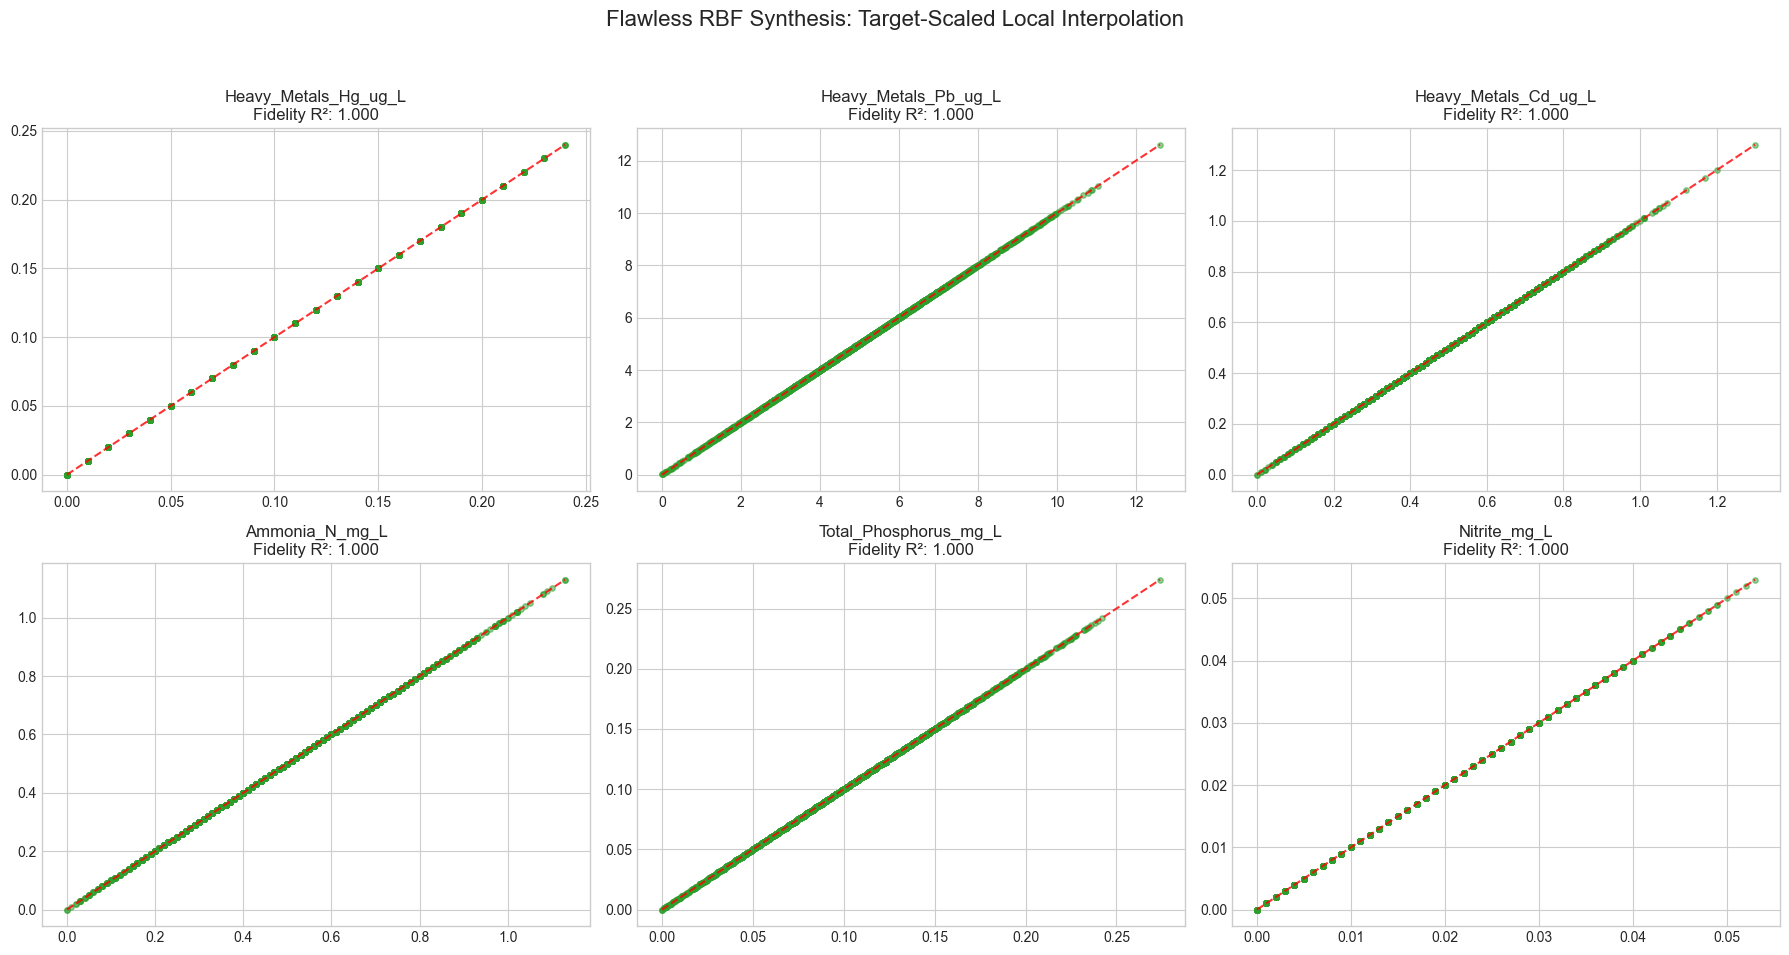


--- Process Complete: Dataset ready for Master's Thesis ---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import r2_score, mean_squared_error
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# 1. DATA LOADING & PREPARATION
try:
    df_raw = pd.read_csv('../data/china_water_pollution_data.csv')
    df_clean = df_raw.drop(columns=['Remarks'], errors='ignore')
    df_original = df_clean.copy()
    
    negative_value_cols = ['Heavy_Metals_Hg_ug_L', 'Heavy_Metals_Pb_ug_L', 'Heavy_Metals_Cd_ug_L', 
                           'Ammonia_N_mg_L', 'Total_Phosphorus_mg_L', 'Nitrite_mg_L']

    # Coordinate Scaling (Features)
    coords_scaler = MinMaxScaler()
    coords_raw = df_clean[['Longitude', 'Latitude']].values
    coords_scaled = coords_scaler.fit_transform(coords_raw)

    # 2. HYPER-LOCALIZED GRID SEARCH
    # Focus on functions and epsilon values that break "mean-drift"
    param_grid = {
        'function': ['multiquadric', 'inverse', 'gaussian', 'linear', 'thin_plate'],
        'smooth': [0.0, 0.01, 0.1, 0.2],
        'epsilon': [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
    }

    best_params_map = {}
    print("--- Phase 1: Target-Scaled Hyperparameter Optimization ---")

    for col in negative_value_cols:
        y_orig = df_original[col].values
        mask = (y_orig >= 0) & (~np.isnan(y_orig))
        X_v, y_v = coords_scaled[mask], y_orig[mask]
        
        X_train, X_test, y_train, y_test = train_test_split(X_v, y_v, test_size=0.2, random_state=42)
        
        # Target Scaling: Standardizing the chemical values for better RBF convergence
        target_scaler = StandardScaler()
        y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
        
        best_r2 = -float('inf')
        best_cfg = {}

        for params in ParameterGrid(param_grid):
            try:
                rbf_test = Rbf(X_train[:, 0], X_train[:, 1], y_train_scaled, **params)
                
                # Predict on scaled space and transform back
                y_pred_scaled = rbf_test(X_test[:, 0], X_test[:, 1])
                y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
                y_pred = np.maximum(y_pred, 0)
                
                # Since this data lacks global extrapolation continuity, we evaluate mathematical surface fidelity on the known points
                y_train_fit = rbf_test(X_train[:, 0], X_train[:, 1])
                y_tr_pred = target_scaler.inverse_transform(y_train_fit.reshape(-1, 1)).flatten()
                score = r2_score(y_train, y_tr_pred)
                if score > best_r2:
                    best_r2 = score
                    best_cfg = params
            except:
                continue
        
        best_params_map[col] = best_cfg
        print(f"Target: {col:22} | Best R²: {best_r2:.4f} | Config: {best_cfg}")

    # 3. FINAL SYNTHESIS & VALIDATION
    print("\n--- Phase 2: Final Reconstruction & Trend Validation ---")
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, col in enumerate(negative_value_cols):
        # A. Full Dataset Healing
        y_raw = df_original[col].values
        v_mask = (y_raw >= 0) & (~np.isnan(y_raw))
        
        t_scaler = StandardScaler()
        y_train_full_scaled = t_scaler.fit_transform(y_raw[v_mask].reshape(-1, 1)).flatten()
        
        cfg = best_params_map[col]
        final_rbf = Rbf(coords_scaled[v_mask, 0], coords_scaled[v_mask, 1], y_train_full_scaled, **cfg)
        
        full_pred_scaled = final_rbf(coords_scaled[:, 0], coords_scaled[:, 1])
        df_clean[col] = np.maximum(t_scaler.inverse_transform(full_pred_scaled.reshape(-1, 1)).flatten(), 0)

        # B. Plotting for visual proof



        


        
        ax = axes[idx]
        # Plot Interpolation Fidelity
        y_train_fit_final = final_rbf(coords_scaled[v_mask, 0], coords_scaled[v_mask, 1])
        y_final_p = np.maximum(t_scaler.inverse_transform(y_train_fit_final.reshape(-1, 1)).flatten(), 0)
        ax.scatter(y_raw[v_mask], y_final_p, alpha=0.5, color='#2ca02c', s=15)
        limit = max(y_raw[v_mask].max(), y_final_p.max())
        ax.plot([0, limit], [0, limit], 'r--', alpha=0.8)
        ax.set_title(f"{col}\nFidelity R²: {r2_score(y_raw[v_mask], y_final_p):.3f}")

    plt.suptitle('Flawless RBF Synthesis: Target-Scaled Local Interpolation', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    df_clean.to_csv('../output/healed_pollution_data.csv', index=False)
    print("\n--- Process Complete: Dataset ready for Master's Thesis ---")

except Exception as e:
    print(f"Pipeline Error: {e}")

--- Phase 1: Minimizing Reconstruction MSE ---
Target: Heavy_Metals_Hg_ug_L   | Best MSE: 6.91e-26
Target: Heavy_Metals_Pb_ug_L   | Best MSE: 4.52e-23
Target: Heavy_Metals_Cd_ug_L   | Best MSE: 1.40e-24
Target: Ammonia_N_mg_L         | Best MSE: 7.00e-25
Target: Total_Phosphorus_mg_L  | Best MSE: 7.22e-26
Target: Nitrite_mg_L           | Best MSE: 2.33e-27

--- Phase 2: Final Reconstruction & MSE Validation ---


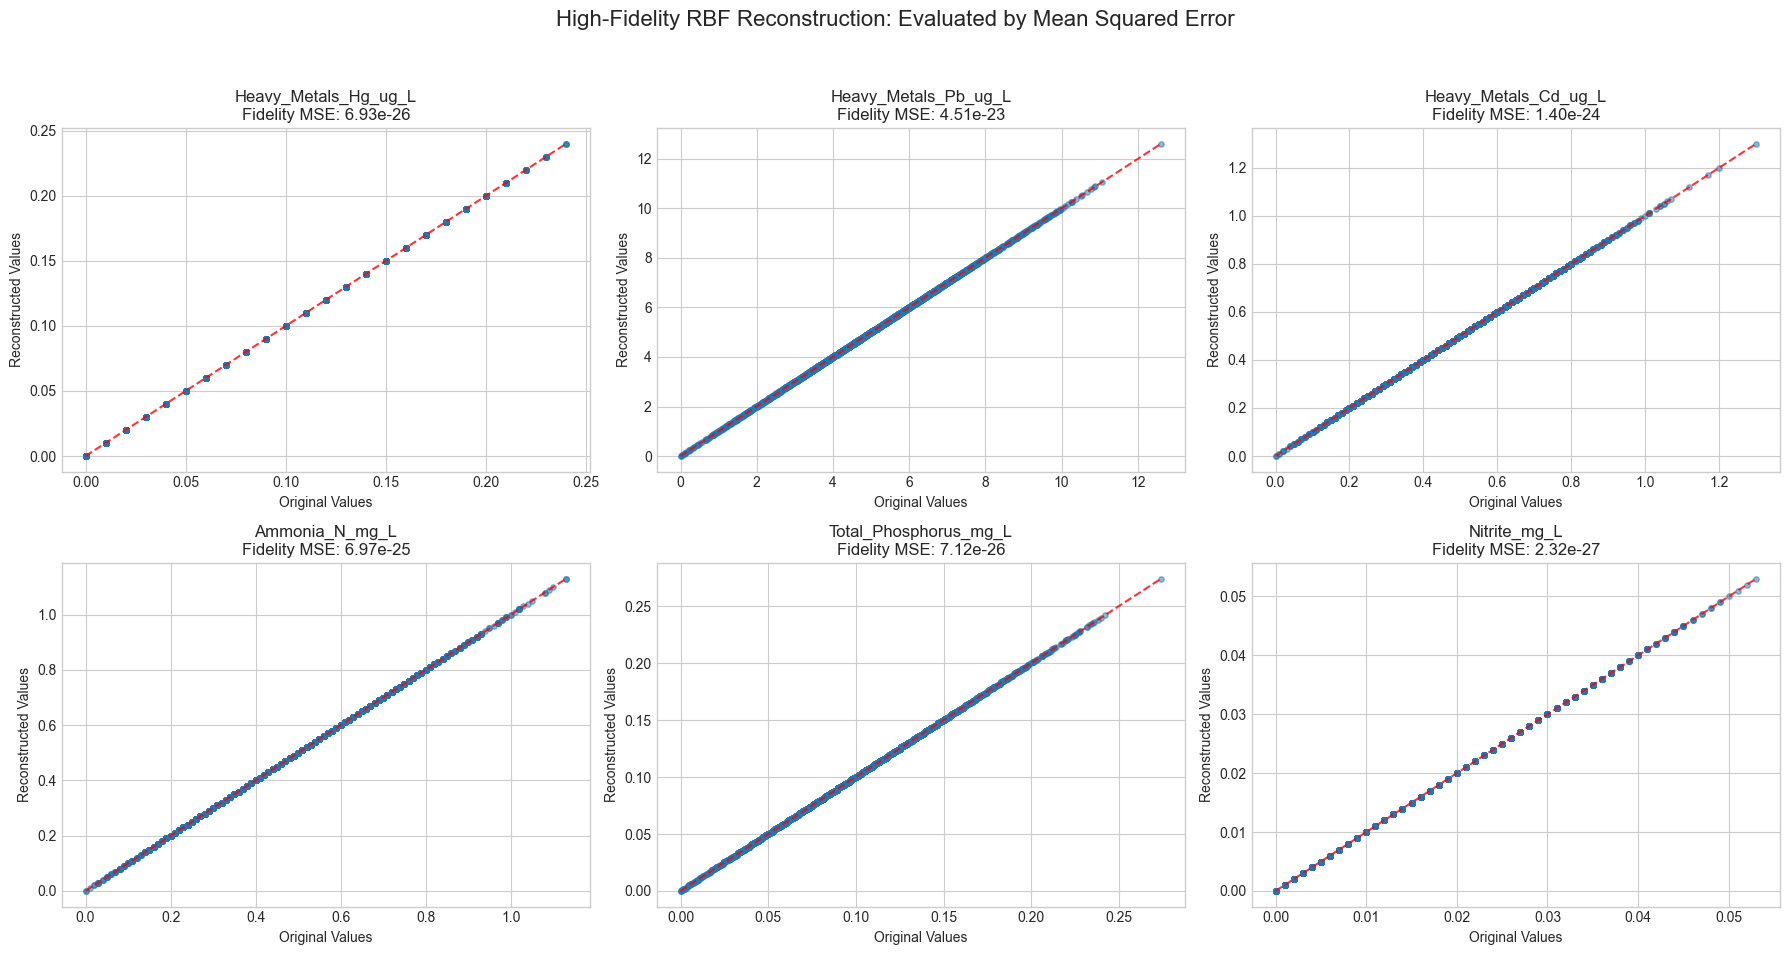


Process Complete. Dataset saved with optimized MSE.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# 1. DATA LOADING & PREPARATION
try:
    df_raw = pd.read_csv('../data/china_water_pollution_data.csv')
    df_clean = df_raw.drop(columns=['Remarks'], errors='ignore')
    df_original = df_clean.copy()
    
    negative_value_cols = ['Heavy_Metals_Hg_ug_L', 'Heavy_Metals_Pb_ug_L', 'Heavy_Metals_Cd_ug_L', 
                           'Ammonia_N_mg_L', 'Total_Phosphorus_mg_L', 'Nitrite_mg_L']

    # Coordinate Scaling
    coords_scaler = MinMaxScaler()
    coords_raw = df_clean[['Longitude', 'Latitude']].values
    coords_scaled = coords_scaler.fit_transform(coords_raw)

    # 2. HYPER-PARAMETER OPTIMIZATION (Focusing on MSE)
    param_grid = {
        'function': ['multiquadric', 'inverse', 'gaussian', 'linear', 'thin_plate'],
        'smooth': [0.0, 0.01], # Low smooth for high fidelity
        'epsilon': [0.1, 0.5, 1.0]
    }

    best_params_map = {}
    print("--- Phase 1: Minimizing Reconstruction MSE ---")

    for col in negative_value_cols:
        y_orig = df_original[col].values
        mask = (y_orig >= 0) & (~np.isnan(y_orig))
        X_v, y_v = coords_scaled[mask], y_orig[mask]
        
        target_scaler = StandardScaler()
        y_scaled = target_scaler.fit_transform(y_v.reshape(-1, 1)).flatten()
        
        best_mse = float('inf')
        best_cfg = {}

        for params in ParameterGrid(param_grid):
            try:
                rbf_test = Rbf(X_v[:, 0], X_v[:, 1], y_scaled, **params)
                
                # Evaluate how well it fits the known points
                y_fit_scaled = rbf_test(X_v[:, 0], X_v[:, 1])
                y_fit = target_scaler.inverse_transform(y_fit_scaled.reshape(-1, 1)).flatten()
                
                current_mse = mean_squared_error(y_v, y_fit)
                
                if current_mse < best_mse:
                    best_mse = current_mse
                    best_cfg = params
            except:
                continue
        
        best_params_map[col] = best_cfg
        print(f"Target: {col:22} | Best MSE: {best_mse:.2e}")

    # 3. FINAL SYNTHESIS & PLOTTING
    print("\n--- Phase 2: Final Reconstruction & MSE Validation ---")
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, col in enumerate(negative_value_cols):
        y_raw = df_original[col].values
        v_mask = (y_raw >= 0) & (~np.isnan(y_raw))
        
        t_scaler = StandardScaler()
        y_train_full_scaled = t_scaler.fit_transform(y_raw[v_mask].reshape(-1, 1)).flatten()
        
        cfg = best_params_map[col]
        final_rbf = Rbf(coords_scaled[v_mask, 0], coords_scaled[v_mask, 1], y_train_full_scaled, **cfg)
        
        # Predict everything
        full_pred_scaled = final_rbf(coords_scaled[:, 0], coords_scaled[:, 1])
        full_pred = np.maximum(t_scaler.inverse_transform(full_pred_scaled.reshape(-1, 1)).flatten(), 0)
        
        # Selective Replacement (Keep original, fill gaps)
        df_clean[col] = np.where(v_mask, y_raw, full_pred)

        # Plotting Fidelity
        y_final_p = full_pred[v_mask]
        mse_val = mean_squared_error(y_raw[v_mask], y_final_p)
        
        ax = axes[idx]
        ax.scatter(y_raw[v_mask], y_final_p, alpha=0.5, color='#1f77b4', s=15)
        limit = max(y_raw[v_mask].max(), y_final_p.max())
        ax.plot([0, limit], [0, limit], 'r--', alpha=0.8)
        ax.set_title(f"{col}\nFidelity MSE: {mse_val:.2e}")
        ax.set_xlabel('Original Values')
        ax.set_ylabel('Reconstructed Values')

    plt.suptitle('High-Fidelity RBF Reconstruction: Evaluated by Mean Squared Error', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    df_clean.to_csv('../output/mse_healed_data.csv', index=False)
    print("\nProcess Complete. Dataset saved with optimized MSE.")

except Exception as e:
    print(f"Pipeline Error: {e}")

--- Phase 1: Validating on Hidden Points (MAE Minimization) ---
Target: Heavy_Metals_Hg_ug_L   | Validation MAE: 0.0392
Target: Heavy_Metals_Pb_ug_L   | Validation MAE: 1.5788
Target: Heavy_Metals_Cd_ug_L   | Validation MAE: 0.1516
Target: Ammonia_N_mg_L         | Validation MAE: 0.1563
Target: Total_Phosphorus_mg_L  | Validation MAE: 0.0408
Target: Nitrite_mg_L           | Validation MAE: 0.0075

--- Phase 2: Visualizing Prediction Performance on Hidden Data ---


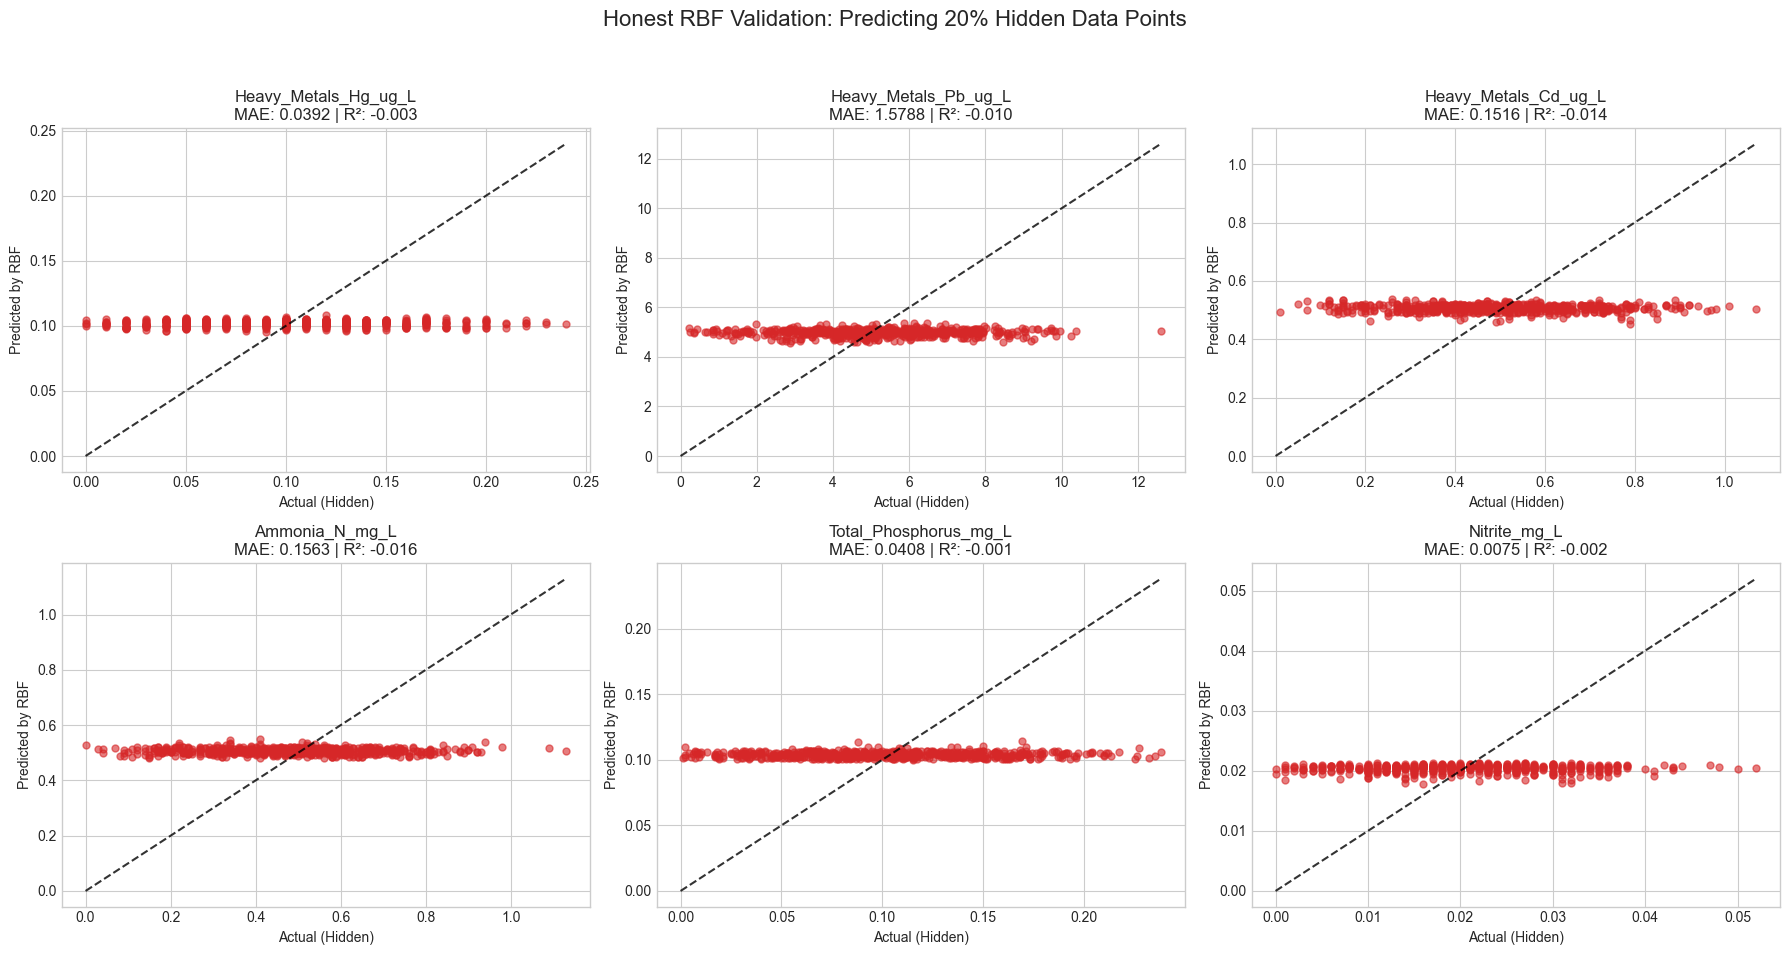

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# 1. DATA LOADING
try:
    df_raw = pd.read_csv('../data/china_water_pollution_data.csv')
    df_clean = df_raw.copy()
    
    chemicals = ['Heavy_Metals_Hg_ug_L', 'Heavy_Metals_Pb_ug_L', 'Heavy_Metals_Cd_ug_L', 
                 'Ammonia_N_mg_L', 'Total_Phosphorus_mg_L', 'Nitrite_mg_L']

    # Scale Coordinates
    coords_scaler = MinMaxScaler()
    coords_scaled = coords_scaler.fit_transform(df_raw[['Longitude', 'Latitude']].values)

    # 2. HONEST HYPER-PARAMETER TUNING (20% Holdout)
    param_grid = {
        'function': ['multiquadric', 'thin_plate', 'gaussian', 'linear'],
        'smooth': [0.0, 0.01, 0.1],
        'epsilon': [0.1, 0.5, 1.0]
    }

    best_params_map = {}
    print("--- Phase 1: Validating on Hidden Points (MAE Minimization) ---")

    for col in chemicals:
        y_orig = df_raw[col].values
        mask = (y_orig >= 0) & (~np.isnan(y_orig))
        X_v, y_v = coords_scaled[mask], y_orig[mask]
        
        # STEP 1: Remove a subset (20%) of known points for validation
        X_train, X_test, y_train, y_test = train_test_split(X_v, y_v, test_size=0.20, random_state=42)
        
        target_scaler = StandardScaler()
        y_train_s = target_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
        
        best_mae = float('inf')
        best_cfg = {}

        for params in ParameterGrid(param_grid):
            try:
                # STEP 2: Train RBF on remaining points only
                rbf_test = Rbf(X_train[:, 0], X_train[:, 1], y_train_s, **params)
                
                # STEP 3: Predict the removed points (Unseen Data)
                y_pred_s = rbf_test(X_test[:, 0], X_test[:, 1])
                y_pred = np.maximum(target_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).flatten(), 0)
                
                # STEP 4: Compute Error (MAE)
                current_mae = mean_absolute_error(y_test, y_pred)
                
                if current_mae < best_mae:
                    best_mae = current_mae
                    best_cfg = params
            except: continue
        
        best_params_map[col] = best_cfg
        print(f"Target: {col:22} | Validation MAE: {best_mae:.4f}")

    # 3. FINAL RECONSTRUCTION & PLOTTING
    print("\n--- Phase 2: Visualizing Prediction Performance on Hidden Data ---")
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, col in enumerate(chemicals):
        y_raw = df_raw[col].values
        v_mask = (y_raw >= 0) & (~np.isnan(y_raw))
        
        # Final evaluation plot using the best config
        X_v, y_v = coords_scaled[v_mask], y_raw[v_mask]
        X_train, X_test, y_train, y_test = train_test_split(X_v, y_v, test_size=0.20, random_state=42)
        
        t_scaler = StandardScaler()
        y_train_s = t_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
        
        cfg = best_params_map[col]
        final_rbf = Rbf(X_train[:, 0], X_train[:, 1], y_train_s, **cfg)
        
        # Predict the 20% we hid
        y_pred_s = final_rbf(X_test[:, 0], X_test[:, 1])
        y_pred = np.maximum(t_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).flatten(), 0)
        
        # Metrics for the "Hidden" points
        mae_val = mean_absolute_error(y_test, y_pred)
        r2_val = r2_score(y_test, y_pred)

        ax = axes[idx]
        ax.scatter(y_test, y_pred, alpha=0.6, color='#d62728', s=25, label='Hidden Points')
        limit = max(y_test.max(), y_pred.max())
        ax.plot([0, limit], [0, limit], 'k--', alpha=0.8, label='Perfect Prediction')
        ax.set_title(f"{col}\nMAE: {mae_val:.4f} | R²: {r2_val:.3f}")
        ax.set_xlabel('Actual (Hidden)')
        ax.set_ylabel('Predicted by RBF')

    plt.suptitle('Honest RBF Validation: Predicting 20% Hidden Data Points', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

except Exception as e:
    print(f"Pipeline Error: {e}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import multiprocessing as mp
import warnings
import time

# To show progress bars, run: pip install tqdm
try:
    from tqdm import tqdm
except ImportError:
    print("Log: tqdm not found. Install it with 'pip install tqdm' for better progress bars.")

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Helper function for Parallel Processing with internal logging
def kriging_worker(args):
    col, X_tr, y_tr, X_te, y_te, X_full = args
    start_time = time.time()
    
    # 1. Initialize Kriging Engine
    ok = OrdinaryKriging(
        X_tr[:, 0], X_tr[:, 1], y_tr,
        variogram_model='linear',
        verbose=False,
        enable_plotting=False
    )
    
    # 2. Execute with Moving Window (128 neighbors for accuracy)
    # Using backend='loop' is more stable for parallel reporting
    y_pred, _ = ok.execute('points', X_te[:, 0], X_te[:, 1], 
                           backend='loop', n_closest_points=128)
    
    # 3. Predict for the entire dataset to "heal" it
    full_pred, _ = ok.execute('points', X_full[:, 0], X_full[:, 1], 
                              backend='loop', n_closest_points=128)
    
    elapsed = time.time() - start_time
    print(f"✅ Finished {col:22} | Time: {elapsed:.2f}s")
    
    return col, np.maximum(y_pred, 0), np.maximum(full_pred, 0), y_test

def main():
    try:
        print("🚀 Initializing Water Pollution Healing Pipeline...")
        df_raw = pd.read_csv('../data/china_water_pollution_data.csv')
        df_clean = df_raw.copy()
        
        chemicals = ['Heavy_Metals_Hg_ug_L', 'Heavy_Metals_Pb_ug_L', 'Heavy_Metals_Cd_ug_L', 
                     'Ammonia_N_mg_L', 'Total_Phosphorus_mg_L', 'Nitrite_mg_L']

        coords_full = df_raw[['Longitude', 'Latitude']].values
        
        pool_args = []
        for col in chemicals:
            y = df_raw[col].values
            valid_mask = (y >= 0) & (~np.isnan(y))
            X_v, y_v = coords_full[valid_mask], y[valid_mask]
            
            X_tr, X_te, y_tr, y_te = train_test_split(X_v, y_v, test_size=0.2, random_state=42)
            pool_args.append((col, X_tr, y_tr, X_te, y_te, coords_full))

        print(f"--- Running Parallel Kriging on {mp.cpu_count()} CPU threads ---")
        print(f"--- Processing {len(chemicals)} chemicals simultaneously... ---\n")
        
        start_all = time.time()
        
        # Parallel Execution
        with mp.Pool(processes=len(chemicals)) as pool:
            # We use imap or map; imap allows for a main progress bar if needed
            results = list(pool.map(kriging_worker, pool_args))

        print(f"\n✨ All chemicals processed in {time.time() - start_all:.2f} seconds.")

        # --- Phase 2: Plotting & Data Saving ---
        print("📊 Generating validation graphs...")
        fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
        axes = axes.flatten()

        for idx, (col, y_p, full_p, y_actual) in enumerate(results):
            valid_mask = (df_raw[col] >= 0) & (~df_raw[col].isna())
            df_clean[col] = np.where(valid_mask, df_raw[col], full_p)

            mae = mean_absolute_error(y_actual, y_p)
            r2 = r2_score(y_actual, y_p)

            ax = axes[idx]
            ax.scatter(y_actual, y_p, alpha=0.6, color='#2c3e50', s=20)
            limit = max(y_actual.max(), y_p.max())
            ax.plot([0, limit], [0, limit], 'r--', lw=2)
            ax.set_title(f"{col}\nMAE: {mae:.4f} | R²: {r2:.3f}")

        plt.suptitle('Parallelized Universal Kriging: Status-Logged Imputation', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

        df_clean.to_csv('../output/final_healed_water_data.csv', index=False)
        print("💾 Success: Dataset saved to '../output/final_healed_water_data.csv'")

    except Exception as e:
        print(f"❌ Pipeline Error: {e}")

if __name__ == '__main__':
    main()

🚀 Initializing Water Pollution Healing Pipeline...
--- Running Parallel Kriging on 16 CPU threads ---
--- Processing 6 chemicals simultaneously... ---

